# Experiment 5: Support Vector Machine (SVM)

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Load Dataset

In [2]:
df = pd.read_csv("data.csv")

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Check Shape

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (569, 33)


# Display Column Names

In [4]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='str')


# check Information

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

# Check Missing values

In [6]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

# Remove Unnecessary Columns

In [7]:
df = df.drop(
    columns=['id', 'Unnamed: 32'],
    errors='ignore'
)

print(df.shape)

(569, 31)


# Convert Target Variables

In [8]:
df['diagnosis'] = df['diagnosis'].map({
    'M': 1,
    'B': 0
})

print(df['diagnosis'].value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


# Separate X and Y

In [9]:
X = df.drop('diagnosis', axis=1)

y = df['diagnosis']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


# Split dataset

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


# Standardize Data

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled[:5])

[[ 5.18558727e-01  8.91825791e-01  4.24631702e-01  3.83925436e-01
  -9.74743706e-01 -6.89771505e-01 -6.88586446e-01 -3.98175254e-01
  -1.03915470e+00 -8.25056321e-01 -1.09317755e-01 -5.59755400e-02
  -2.10096206e-01 -1.59132582e-02 -1.00518399e+00 -9.11941990e-01
  -6.62815884e-01 -6.52561081e-01 -7.01889114e-01 -2.75393571e-01
   5.79797697e-01  1.31324246e+00  4.66908134e-01  4.45982711e-01
  -5.96154777e-01 -6.34722227e-01 -6.10227299e-01 -2.35743918e-01
   5.45663235e-02  2.18367276e-02]
 [-5.16364088e-01 -1.63971029e+00 -5.41348716e-01 -5.42961327e-01
   4.76219058e-01 -6.31833818e-01 -6.04281166e-01 -3.03074908e-01
   5.21543093e-01 -4.54522896e-01 -6.04377961e-01 -1.00104604e+00
  -5.85429002e-01 -4.93453793e-01  4.03212009e-01 -7.68173276e-01
  -4.79187222e-01  1.14508478e-01 -1.42950761e-01 -5.77397732e-01
  -5.82458953e-01 -1.69029101e+00 -6.11934288e-01 -5.87013537e-01
   2.73581959e-01 -8.14844486e-01 -7.12666415e-01 -3.23207881e-01
  -1.37576237e-01 -9.04401643e-01]
 [-3.6

# Create SVM Model

In [13]:
model = SVC(
    kernel='linear',
    C=1.0
)

# Train the Model

In [14]:
model.fit(
    X_train_scaled,
    y_train
)

print("SVM model trained successfully.")

SVM model trained successfully.


# Make the Predictions

In [16]:
y_pred = model.predict(X_test_scaled)

print("Predicted values:")
print(y_pred)

Predicted values:
[0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 0 0
 0 1 0 0 0 1 0 0 1 0 1 0 0 1 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 1 0 1 1 0
 0 0 0 1 0 1 1 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0
 0 0 1]


# Calculate Accuracy

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

print(
    "Accuracy Percentage:",
    accuracy * 100,
    "%"
)

Accuracy: 0.9649122807017544
Accuracy Percentage: 96.49122807017544 %


# Confusion Matrix

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[72  0]
 [ 4 38]]


# Visulaize Confusion Matrix

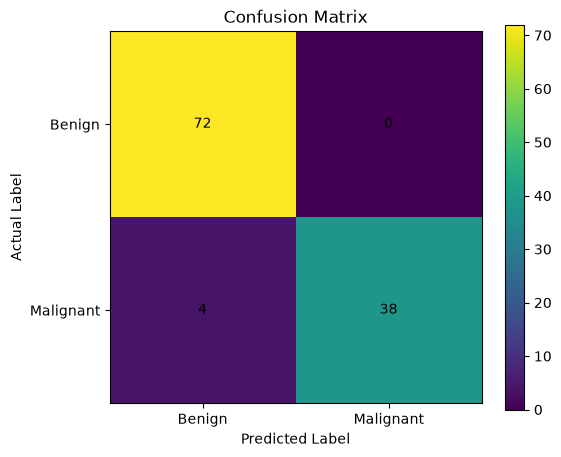

In [19]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ['Benign', 'Malignant'])
plt.yticks([0, 1], ['Benign', 'Malignant'])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.show()

# Classification Report

In [20]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            'Benign',
            'Malignant'
        ]
    )
)

              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



# Test Different Kernels

In [21]:
kernels = [
    'linear',
    'poly',
    'rbf',
    'sigmoid'
]

for kernel in kernels:

    svm_model = SVC(
        kernel=kernel,
        C=1.0
    )

    svm_model.fit(
        X_train_scaled,
        y_train
    )

    prediction = svm_model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        prediction
    )

    print(
        kernel,
        "Accuracy:",
        round(acc * 100, 2),
        "%"
    )

linear Accuracy: 96.49 %
poly Accuracy: 88.6 %
rbf Accuracy: 97.37 %
sigmoid Accuracy: 94.74 %


# Compare Kernals Graphically

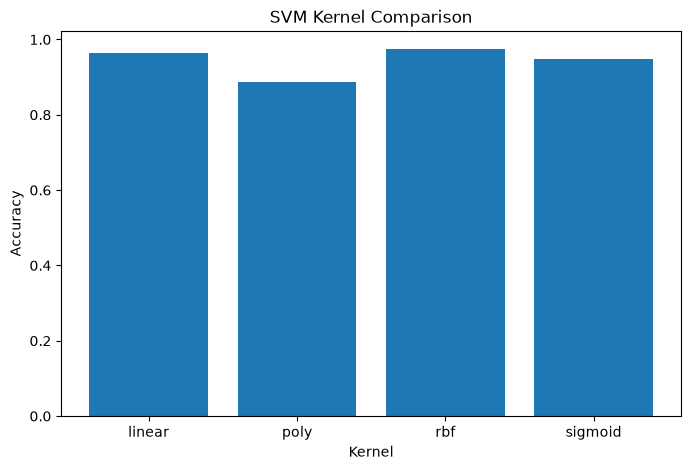

In [22]:
kernel_names = []
accuracies = []

for kernel in kernels:

    svm_model = SVC(
        kernel=kernel,
        C=1.0
    )

    svm_model.fit(
        X_train_scaled,
        y_train
    )

    prediction = svm_model.predict(
        X_test_scaled
    )

    acc = accuracy_score(
        y_test,
        prediction
    )

    kernel_names.append(kernel)
    accuracies.append(acc)

plt.figure(figsize=(8, 5))

plt.bar(
    kernel_names,
    accuracies
)

plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison")

plt.show()